# Deterministic FWHT Compression Model (from `docs/main.tex`)

This notebook implements the deterministic pipeline described in the FWHT subsection:

1. Decimation in frequency (`\downarrow K/M`).
2. Standardization with side information (`b_t`).
3. Optional invertible non-linear mapping `g_{nl}(.)`.
4. Orthonormal FWHT with zero-padding to power-of-two length.
5. Top-`K` sparsification + scalar quantization for payload (`b_s`).
6. Inverse FWHT and inverse preprocessing for reconstruction.

The implementation is fully deterministic and training-free, matching the formulation in `docs/main.tex`.


In [2]:
from __future__ import annotations

from dataclasses import dataclass, replace
from pathlib import Path
from typing import Dict, Iterable, Literal, Tuple

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

Array1D = NDArray[np.float64]


In [3]:
@dataclass(frozen=True)
class StandardizationSideInfo:
    """Stores per-frame standardization parameters sent as side information (`b_t`)."""

    mean: float  # Mean of the decimated frame used for centering
    std: float   # Standard deviation of the decimated frame used for scaling


@dataclass(frozen=True)
class FWHTConfig:
    """Holds deterministic FWHT compressor hyperparameters and payload assumptions."""

    decimation_factor: int = 2
    top_k: int = 64
    quant_step: float = 0.02
    nonlinear_mode: Literal["identity", "signed_log1p", "asinh"] = "signed_log1p"
    nonlinear_alpha: float = 2.0
    side_info_bits: int = 16
    value_bits: int = 16


@dataclass(frozen=True)
class FWHTPacket:
    """Represents the compressed payload generated by the FWHT pipeline."""

    original_length_samples: int
    decimated_length_samples: int
    hadamard_length_samples: int
    side_info: StandardizationSideInfo
    topk_indices: NDArray[np.int64]
    quantized_values: NDArray[np.int32]
    quant_step: float
    nonlinear_mode: Literal["identity", "signed_log1p", "asinh"]
    nonlinear_alpha: float


In [4]:
def load_psd_dataset(
    dataset_path: Path,  # Path to the NPZ PSD dataset
) -> Tuple[NDArray[np.float32], NDArray[np.float64], Dict[str, object]]:  # (frames, frequency grid, metadata)
    """Loads normalized PSD frames and metadata from disk.

    Purpose:
    - Provide a deterministic dataset loader for the FWHT experiment.

    Parameters:
    - dataset_path: NPZ file containing `X`, `freqs_hz`, and metadata fields.

    Returns:
    - Tuple with PSD frames (`X`), frequency grid (`freqs_hz`), and scalar metadata.

    Side effects:
    - Reads the NPZ file from disk.
    """
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset not found: {dataset_path}")

    # Load arrays and extract scalar metadata from the NPZ container.
    dataset_npz = np.load(dataset_path, allow_pickle=True)
    frames_psd = dataset_npz["X"].astype(np.float32)
    freqs_hz = dataset_npz["freqs_hz"].astype(np.float64)

    metadata: Dict[str, object] = {
        "gmin": float(dataset_npz["gmin"]),
        "gmax": float(dataset_npz["gmax"]),
        "normalize_mode": str(dataset_npz["normalize_mode"]),
    }
    return frames_psd, freqs_hz, metadata


def decimate_frequency_bins(
    frame_psd: Array1D,       # Input PSD frame [samples]
    decimation_factor: int,   # Downsampling factor M/K
) -> Array1D:                 # Decimated PSD frame [samples]
    """Downsamples a PSD frame by average pooling contiguous frequency bins.

    Purpose:
    - Implement deterministic front-end decimation from the system model.

    Parameters:
    - frame_psd: One-dimensional PSD frame on the original frequency grid.
    - decimation_factor: Number of adjacent bins averaged into one output bin.

    Returns:
    - Decimated PSD frame with length `floor(N / decimation_factor)`.

    Side effects:
    - None.

    Assumptions:
    - `frame_psd` is one-dimensional and non-empty.
    - `decimation_factor >= 1`.
    """
    if frame_psd.ndim != 1:
        raise ValueError("frame_psd must be one-dimensional")
    if decimation_factor < 1:
        raise ValueError("decimation_factor must be >= 1")

    # Trim trailing samples that cannot form a complete pooling block.
    trimmed_length = (frame_psd.size // decimation_factor) * decimation_factor
    if trimmed_length == 0:
        raise ValueError("decimation_factor is too large for frame length")

    trimmed = frame_psd[:trimmed_length]

    # Average each block to reduce bandwidth while preserving coarse spectral shape.
    decimated = trimmed.reshape(-1, decimation_factor).mean(axis=1)
    return decimated.astype(np.float64)


def upsample_linear(
    frame_decimated: Array1D,  # Decimated PSD frame [samples]
    target_length: int,        # Desired output length [samples]
) -> Array1D:                  # Upsampled PSD frame [samples]
    """Upsamples a decimated frame to the original grid via linear interpolation.

    Purpose:
    - Implement the inverse `U_{M/K}` stage in a simple deterministic way.

    Parameters:
    - frame_decimated: Input frame on the reduced grid.
    - target_length: Target number of bins on the original grid.

    Returns:
    - Reconstructed frame with `target_length` samples.

    Side effects:
    - None.
    """
    if frame_decimated.ndim != 1:
        raise ValueError("frame_decimated must be one-dimensional")
    if target_length < 1:
        raise ValueError("target_length must be >= 1")

    if frame_decimated.size == 1:
        return np.full((target_length,), float(frame_decimated[0]), dtype=np.float64)

    # Build normalized axes to keep interpolation independent of absolute length.
    source_axis = np.linspace(0.0, 1.0, frame_decimated.size)
    target_axis = np.linspace(0.0, 1.0, target_length)
    return np.interp(target_axis, source_axis, frame_decimated).astype(np.float64)


def standardize_frame(
    frame: Array1D,          # Input frame to standardize
    eps: float = 1e-8,       # Numerical lower bound for the standard deviation
) -> Tuple[Array1D, StandardizationSideInfo]:  # (standardized frame, side info)
    """Standardizes one frame and returns the side information needed for inversion.

    Purpose:
    - Implement `Std(S'_t; t_t)` while producing side information bits `b_t`.

    Parameters:
    - frame: Input one-dimensional frame.
    - eps: Lower bound to avoid division by zero.

    Returns:
    - Standardized frame and a `StandardizationSideInfo(mean, std)` object.

    Side effects:
    - None.
    """
    if frame.ndim != 1:
        raise ValueError("frame must be one-dimensional")

    # Estimate affine normalization parameters for this frame.
    mean_value = float(np.mean(frame))
    std_value = float(np.std(frame))
    safe_std = max(std_value, eps)

    standardized = (frame - mean_value) / safe_std
    side_info = StandardizationSideInfo(mean=mean_value, std=safe_std)
    return standardized.astype(np.float64), side_info


def destandardize_frame(
    standardized: Array1D,                 # Standardized frame
    side_info: StandardizationSideInfo,    # Stored (mean, std) parameters
) -> Array1D:                              # Frame in the original decimated scale
    """Inverts frame standardization using transmitted side information."""
    if standardized.ndim != 1:
        raise ValueError("standardized must be one-dimensional")

    # Restore original scale by reversing affine normalization.
    return (standardized * side_info.std + side_info.mean).astype(np.float64)


In [5]:
def apply_nonlinear_map(
    values: Array1D,                                              # Standardized values
    mode: Literal["identity", "signed_log1p", "asinh"],          # Non-linear map selector
    alpha: float,                                                 # Shape parameter for the map
) -> Array1D:                                                     # Transformed values
    """Applies an invertible pointwise map `g_nl(.)` before transform coding.

    Purpose:
    - Reduce heavy tails so sparse/quantized coefficients become more efficient.

    Parameters:
    - values: Input one-dimensional standardized signal.
    - mode: Map type (`identity`, `signed_log1p`, or `asinh`).
    - alpha: Positive shape parameter controlling non-linearity strength.

    Returns:
    - Transformed vector in the same shape as input.

    Side effects:
    - None.
    """
    if values.ndim != 1:
        raise ValueError("values must be one-dimensional")
    if alpha <= 0.0:
        raise ValueError("alpha must be > 0")

    # Keep the identity path for ablation or when non-linearity is disabled.
    if mode == "identity":
        return values.astype(np.float64)

    # Signed log1p provides log-like dynamic range compression for signed inputs.
    if mode == "signed_log1p":
        return (np.sign(values) * np.log1p(alpha * np.abs(values)) / alpha).astype(np.float64)

    # asinh is smooth around zero and log-like for large magnitudes.
    if mode == "asinh":
        return (np.arcsinh(alpha * values) / alpha).astype(np.float64)

    raise ValueError(f"Unsupported nonlinear mode: {mode}")


def invert_nonlinear_map(
    transformed: Array1D,                                         # Values in transformed domain
    mode: Literal["identity", "signed_log1p", "asinh"],          # Non-linear map selector
    alpha: float,                                                 # Shape parameter used in forward map
) -> Array1D:                                                     # Values in standardized domain
    """Inverts the pointwise non-linear map `g_nl(.)`."""
    if transformed.ndim != 1:
        raise ValueError("transformed must be one-dimensional")
    if alpha <= 0.0:
        raise ValueError("alpha must be > 0")

    # Reverse each mode with its analytical inverse.
    if mode == "identity":
        return transformed.astype(np.float64)
    if mode == "signed_log1p":
        return (np.sign(transformed) * np.expm1(alpha * np.abs(transformed)) / alpha).astype(np.float64)
    if mode == "asinh":
        return (np.sinh(alpha * transformed) / alpha).astype(np.float64)

    raise ValueError(f"Unsupported nonlinear mode: {mode}")


def next_power_of_two(
    length: int,  # Input vector length [samples]
) -> int:         # Smallest 2^m >= length
    """Returns the next power-of-two length required by FWHT."""
    if length < 1:
        raise ValueError("length must be >= 1")
    return 1 << (length - 1).bit_length()


def pad_with_zeros(
    values: Array1D,     # Input vector to pad
    target_length: int,  # Desired padded length [samples]
) -> Array1D:            # Zero-padded vector
    """Right-pads a vector with zeros up to the requested target length."""
    if values.ndim != 1:
        raise ValueError("values must be one-dimensional")
    if target_length < values.size:
        raise ValueError("target_length must be >= values length")

    if target_length == values.size:
        return values.astype(np.float64)

    padded = np.zeros(target_length, dtype=np.float64)
    padded[: values.size] = values
    return padded


def fwht_orthonormal(
    values: Array1D,  # Input vector of length N=2^m
) -> Array1D:         # FWHT coefficients c=(1/sqrt(N))*H_N*x
    """Computes the orthonormal Fast Walsh-Hadamard Transform.

    Purpose:
    - Implement `c_t = (1/sqrt(N_H)) H_{N_H} sigma_t` exactly as defined in the document.

    Parameters:
    - values: One-dimensional vector with power-of-two length.

    Returns:
    - Orthonormal FWHT coefficients.

    Side effects:
    - None.

    Assumptions:
    - Length is a power of two.
    """
    if values.ndim != 1:
        raise ValueError("values must be one-dimensional")

    n_samples = values.size
    if n_samples < 1 or (n_samples & (n_samples - 1)) != 0:
        raise ValueError("FWHT input length must be a power of two")

    transformed = values.astype(np.float64, copy=True)

    # Apply in-place butterfly stages of the Hadamard transform.
    block_size = 1
    while block_size < n_samples:
        step = block_size * 2
        for start in range(0, n_samples, step):
            upper = transformed[start : start + block_size].copy()
            lower = transformed[start + block_size : start + step].copy()
            transformed[start : start + block_size] = upper + lower
            transformed[start + block_size : start + step] = upper - lower
        block_size = step

    # Scale to obtain an orthonormal transform matrix.
    transformed /= np.sqrt(n_samples)
    return transformed


def inverse_fwht_orthonormal(
    coefficients: Array1D,  # FWHT coefficients of length N=2^m
) -> Array1D:               # Reconstructed vector in the original domain
    """Computes inverse orthonormal FWHT.

    For orthonormal Hadamard transforms, the inverse equals the forward transform:
    `(1/sqrt(N) H_N)^{-1} = (1/sqrt(N) H_N)`.
    """
    return fwht_orthonormal(coefficients)


def select_topk_coefficients(
    coefficients: Array1D,  # Full FWHT coefficient vector
    top_k: int,             # Number of coefficients to keep
) -> Tuple[NDArray[np.int64], Array1D]:  # (indices Omega_t, selected values)
    """Selects the K largest-magnitude coefficients without full sorting.

    Purpose:
    - Build sparse support set `Omega_t` for FWHT payload generation.

    Parameters:
    - coefficients: Transform coefficients.
    - top_k: Number of retained coefficients.

    Returns:
    - Sorted coefficient indices and their floating-point values.

    Side effects:
    - None.
    """
    if coefficients.ndim != 1:
        raise ValueError("coefficients must be one-dimensional")
    if top_k < 0:
        raise ValueError("top_k must be >= 0")

    if top_k == 0:
        return np.empty((0,), dtype=np.int64), np.empty((0,), dtype=np.float64)

    k_effective = min(top_k, coefficients.size)

    # Use argpartition for O(N) selection complexity.
    support = np.argpartition(np.abs(coefficients), -k_effective)[-k_effective:]
    support = np.sort(support.astype(np.int64))
    return support, coefficients[support].astype(np.float64)


def quantize_uniform(
    values: Array1D,      # Continuous values to quantize
    quant_step: float,    # Quantizer step size
) -> NDArray[np.int32]:   # Integer quantization indices
    """Applies scalar uniform quantization to selected FWHT coefficients."""
    if values.ndim != 1:
        raise ValueError("values must be one-dimensional")
    if quant_step <= 0.0:
        raise ValueError("quant_step must be > 0")

    # Round to nearest quantization level in integer index space.
    return np.rint(values / quant_step).astype(np.int32)


def dequantize_uniform(
    q_values: NDArray[np.int32],  # Integer quantization indices
    quant_step: float,            # Quantizer step size
) -> Array1D:                     # Reconstructed continuous values
    """Inverts scalar uniform quantization."""
    if q_values.ndim != 1:
        raise ValueError("q_values must be one-dimensional")
    if quant_step <= 0.0:
        raise ValueError("quant_step must be > 0")

    # Map each integer index back to its quantization centroid.
    return (q_values.astype(np.float64) * quant_step).astype(np.float64)


def build_sparse_vector(
    length: int,                    # Target sparse vector length
    indices: NDArray[np.int64],     # Non-zero locations
    values: Array1D,                # Non-zero values
) -> Array1D:                       # Sparse vector with zeros outside support
    """Reconstructs sparse FWHT coefficients from `(indices, values)` payload."""
    if length < 1:
        raise ValueError("length must be >= 1")
    if indices.ndim != 1 or values.ndim != 1:
        raise ValueError("indices and values must be one-dimensional")
    if indices.size != values.size:
        raise ValueError("indices and values must have the same size")
    if np.any(indices < 0) or np.any(indices >= length):
        raise ValueError("indices must be within [0, length)")

    # Populate retained coefficients and leave all others as zeros.
    sparse = np.zeros(length, dtype=np.float64)
    sparse[indices] = values
    return sparse


In [6]:
def compress_fwht_frame(
    frame_psd: Array1D,    # Original PSD frame S_t(omega)
    config: FWHTConfig,    # Deterministic FWHT configuration
) -> FWHTPacket:           # Compressed payload (b_s, b_t)
    """Compresses one PSD frame using the deterministic FWHT model.

    Purpose:
    - Implement the encoder-side path in `docs/main.tex`:
      decimation -> standardization -> non-linear map -> FWHT -> top-K -> quantization.

    Parameters:
    - frame_psd: Input PSD vector on the original frequency grid.
    - config: Hyperparameters controlling sparsity and quantization.

    Returns:
    - `FWHTPacket` containing side information (`b_t`) and sparse quantized payload (`b_s`).

    Side effects:
    - None.
    """
    if frame_psd.ndim != 1:
        raise ValueError("frame_psd must be one-dimensional")

    # 1) Deterministic front-end decimation.
    frame_decimated = decimate_frequency_bins(frame_psd, config.decimation_factor)

    # 2) Standardize and store side information to invert the affine map later.
    frame_standardized, side_info = standardize_frame(frame_decimated)

    # 3) Optional invertible non-linearity for dynamic-range shaping.
    sigma_t = apply_nonlinear_map(
        frame_standardized,
        mode=config.nonlinear_mode,
        alpha=config.nonlinear_alpha,
    )

    # 4) Zero-pad to power-of-two length required by FWHT.
    hadamard_length = next_power_of_two(sigma_t.size)
    sigma_padded = pad_with_zeros(sigma_t, hadamard_length)

    # 5) Transform to sequency domain and keep top-K magnitude coefficients.
    coefficients = fwht_orthonormal(sigma_padded)
    topk_indices, topk_values = select_topk_coefficients(coefficients, config.top_k)

    # 6) Quantize retained coefficients to form the main payload.
    quantized_values = quantize_uniform(topk_values, config.quant_step)

    return FWHTPacket(
        original_length_samples=int(frame_psd.size),
        decimated_length_samples=int(frame_decimated.size),
        hadamard_length_samples=int(hadamard_length),
        side_info=side_info,
        topk_indices=topk_indices,
        quantized_values=quantized_values,
        quant_step=float(config.quant_step),
        nonlinear_mode=config.nonlinear_mode,
        nonlinear_alpha=float(config.nonlinear_alpha),
    )


def decompress_fwht_frame(
    packet: FWHTPacket,  # Compressed payload generated by `compress_fwht_frame`
) -> Array1D:            # Reconstructed PSD frame on original grid
    """Reconstructs one PSD frame from FWHT sparse payload and side information.

    Purpose:
    - Implement decoder-side path in `docs/main.tex`:
      sparse coeffs -> inverse FWHT -> inverse non-linearity -> de-standardization -> upsampling.

    Parameters:
    - packet: Compressed packet containing `b_s` and `b_t` equivalent fields.

    Returns:
    - Reconstructed PSD frame with the original number of bins.

    Side effects:
    - None.
    """
    # 1) Dequantize sparse coefficient values.
    dequantized_values = dequantize_uniform(packet.quantized_values, packet.quant_step)

    # 2) Rebuild sparse transform vector and apply inverse FWHT.
    sparse_coefficients = build_sparse_vector(
        length=packet.hadamard_length_samples,
        indices=packet.topk_indices,
        values=dequantized_values,
    )
    sigma_padded_hat = inverse_fwht_orthonormal(sparse_coefficients)

    # 3) Remove zero-padding to recover original decimated-domain length.
    sigma_hat = sigma_padded_hat[: packet.decimated_length_samples]

    # 4) Invert non-linearity and standardization.
    standardized_hat = invert_nonlinear_map(
        sigma_hat,
        mode=packet.nonlinear_mode,
        alpha=packet.nonlinear_alpha,
    )
    frame_decimated_hat = destandardize_frame(standardized_hat, packet.side_info)

    # 5) Upsample to the original frequency grid.
    return upsample_linear(frame_decimated_hat, packet.original_length_samples)


def estimate_payload_bits(
    packet: FWHTPacket,  # Compressed payload instance
    config: FWHTConfig,  # Bit assumptions for side info and values
) -> Dict[str, int]:     # Bit-count dictionary {b_t, b_s_indices, b_s_values, total_bits}
    """Estimates payload size in bits for one compressed frame.

    Purpose:
    - Provide a deterministic bit-budget estimate for rate-distortion analysis.

    Parameters:
    - packet: Compressed packet from the FWHT model.
    - config: Contains side-information and value bit-depth assumptions.

    Returns:
    - Dictionary with bit counts for side information, index payload, value payload, and total bits.

    Side effects:
    - None.
    """
    # Side information stores mean and std for per-frame normalization.
    b_t_bits = 2 * int(config.side_info_bits)

    # Index payload uses fixed-length coding with ceil(log2(N_H)) bits/index.
    index_bits_per_symbol = int(np.ceil(np.log2(packet.hadamard_length_samples)))
    b_s_index_bits = int(packet.topk_indices.size * index_bits_per_symbol)

    # Value payload assumes fixed-width integer code for quantized coefficients.
    b_s_value_bits = int(packet.quantized_values.size * int(config.value_bits))

    # Include a small header for `K` and transform length signaling.
    header_bits = int(np.ceil(np.log2(packet.hadamard_length_samples + 1))) + 16

    total_bits = b_t_bits + b_s_index_bits + b_s_value_bits + header_bits
    return {
        "b_t_bits": b_t_bits,
        "b_s_index_bits": b_s_index_bits,
        "b_s_value_bits": b_s_value_bits,
        "header_bits": header_bits,
        "total_bits": total_bits,
    }


def reconstruction_metrics(
    reference: Array1D,  # Ground-truth PSD frame
    estimate: Array1D,   # Reconstructed PSD frame
) -> Dict[str, float]:   # MSE/RMSE/MAE/NMSE/SNR metrics
    """Computes scalar reconstruction metrics for one frame.

    Purpose:
    - Quantify distortion after FWHT compression.

    Parameters:
    - reference: Original PSD values.
    - estimate: Reconstructed PSD values.

    Returns:
    - Dictionary with `mse`, `rmse`, `mae`, `nmse`, and `snr_db`.

    Side effects:
    - None.
    """
    if reference.shape != estimate.shape:
        raise ValueError("reference and estimate must have same shape")

    # Compute error statistics in the PSD amplitude domain.
    error = reference - estimate
    mse = float(np.mean(np.square(error)))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(error)))

    # Normalize by signal power to obtain scale-independent error.
    signal_power = float(np.mean(np.square(reference))) + 1e-12
    nmse = float(mse / signal_power)
    snr_db = float(10.0 * np.log10(signal_power / (mse + 1e-12)))

    return {"mse": mse, "rmse": rmse, "mae": mae, "nmse": nmse, "snr_db": snr_db}


def occupancy_mismatch_rate(
    reference: Array1D,  # Ground-truth PSD frame
    estimate: Array1D,   # Reconstructed PSD frame
    threshold: float,    # Occupancy threshold in normalized PSD units
) -> float:              # Fraction of bins with occupancy disagreement
    """Computes occupancy disagreement rate using a shared threshold rule.

    Purpose:
    - Approximate sensing-level consistency term from the document.

    Parameters:
    - reference: Original PSD values.
    - estimate: Reconstructed PSD values.
    - threshold: Common threshold used for both occupancy maps.

    Returns:
    - Fraction in [0, 1] of mismatched occupancy decisions.

    Side effects:
    - None.
    """
    if reference.shape != estimate.shape:
        raise ValueError("reference and estimate must have same shape")

    # Build binary occupancy masks and compare decisions bin-by-bin.
    ref_occ = reference > threshold
    est_occ = estimate > threshold
    return float(np.mean(ref_occ != est_occ))


def evaluate_fwht_dataset(
    frames_psd: NDArray[np.float32],  # Full PSD dataset [num_frames, num_bins]
    config: FWHTConfig,               # Deterministic FWHT configuration
    frame_indices: Iterable[int],     # Frame subset to evaluate
) -> Dict[str, float]:                # Aggregate rate-distortion summary
    """Evaluates FWHT compression over a subset of frames.

    Purpose:
    - Compute average distortion and payload size to analyze operating points.

    Parameters:
    - frames_psd: Dataset matrix where each row is one PSD frame.
    - config: Model configuration.
    - frame_indices: Indices of frames used in the evaluation.

    Returns:
    - Aggregate metrics including average MSE/NMSE/SNR, occupancy mismatch, and bits/frame.

    Side effects:
    - None.
    """
    mse_values: list[float] = []
    nmse_values: list[float] = []
    snr_values: list[float] = []
    occ_values: list[float] = []
    bit_values: list[int] = []

    for frame_index in frame_indices:
        # Encode/decode one frame following the deterministic pipeline.
        frame_reference = frames_psd[frame_index].astype(np.float64)
        packet = compress_fwht_frame(frame_reference, config)
        frame_estimate = decompress_fwht_frame(packet)

        # Collect waveform-level fidelity metrics.
        metrics = reconstruction_metrics(frame_reference, frame_estimate)
        mse_values.append(metrics["mse"])
        nmse_values.append(metrics["nmse"])
        snr_values.append(metrics["snr_db"])

        # Collect a sensing-oriented occupancy mismatch indicator.
        threshold = float(np.percentile(frame_reference, 75.0))
        occ_values.append(occupancy_mismatch_rate(frame_reference, frame_estimate, threshold))

        # Collect estimated payload size.
        payload_bits = estimate_payload_bits(packet, config)
        bit_values.append(payload_bits["total_bits"])

    return {
        "num_frames": float(len(mse_values)),
        "avg_mse": float(np.mean(mse_values)),
        "avg_nmse": float(np.mean(nmse_values)),
        "avg_snr_db": float(np.mean(snr_values)),
        "avg_occupancy_mismatch": float(np.mean(occ_values)),
        "avg_bits_per_frame": float(np.mean(bit_values)),
    }


In [7]:
DATASET_REL_PATH = Path("data/processed/psd_1024/dataset_psd_1024_norm.npz")
DATASET_CANDIDATES = [
    DATASET_REL_PATH,
    Path("..") / DATASET_REL_PATH,
]

DATASET_PATH: Path | None = None
for candidate_path in DATASET_CANDIDATES:
    if candidate_path.exists():
        DATASET_PATH = candidate_path
        break

if DATASET_PATH is None:
    candidates_str = "\n".join(str(path) for path in DATASET_CANDIDATES)
    raise FileNotFoundError(f"Dataset not found. Tried:\n{candidates_str}")

frames_psd, freqs_hz, dataset_metadata = load_psd_dataset(DATASET_PATH)

print(f"Loaded PSD dataset from: {DATASET_PATH.resolve()}")
print(f"frames_psd shape: {frames_psd.shape}")
print(f"freqs_hz shape:  {freqs_hz.shape}")
print(f"metadata:        {dataset_metadata}")


Loaded PSD dataset from: /home/marti/Code/kl_psd/data/processed/psd_1024/dataset_psd_1024_norm.npz
frames_psd shape: (967, 1024)
freqs_hz shape:  (1024,)
metadata:        {'gmin': -31.256715774536133, 'gmax': 5.902835845947266, 'normalize_mode': 'global_minmax'}


In [8]:
# Baseline deterministic FWHT operating point.
config = FWHTConfig(
    decimation_factor=2,
    top_k=64,
    quant_step=0.02,
    nonlinear_mode="signed_log1p",
    nonlinear_alpha=2.0,
    side_info_bits=16,
    value_bits=16,
)

FRAME_INDEX = 0
frame_reference = frames_psd[FRAME_INDEX].astype(np.float64)

packet = compress_fwht_frame(frame_reference, config)
frame_estimate = decompress_fwht_frame(packet)

frame_metrics = reconstruction_metrics(frame_reference, frame_estimate)
payload_metrics = estimate_payload_bits(packet, config)
occupancy_threshold = float(np.percentile(frame_reference, 75.0))
occ_mismatch = occupancy_mismatch_rate(frame_reference, frame_estimate, occupancy_threshold)

print("FWHT packet summary")
print("-------------------")
print(f"original_length:   {packet.original_length_samples}")
print(f"decimated_length:  {packet.decimated_length_samples}")
print(f"hadamard_length:   {packet.hadamard_length_samples}")
print(f"top_k (effective): {packet.topk_indices.size}")
print(f"side_info(mean,std): ({packet.side_info.mean:.6f}, {packet.side_info.std:.6f})")

print("\nReconstruction metrics")
print("----------------------")
for key, value in frame_metrics.items():
    print(f"{key:>10s}: {value:.6e}")
print(f"occupancy_mismatch: {occ_mismatch:.6e}")

print("\nPayload estimate")
print("----------------")
for key, value in payload_metrics.items():
    print(f"{key:>14s}: {value}")


FWHT packet summary
-------------------
original_length:   1024
decimated_length:  512
hadamard_length:   512
top_k (effective): 64
side_info(mean,std): (0.307141, 0.111032)

Reconstruction metrics
----------------------
       mse: 1.768926e-03
      rmse: 4.205861e-02
       mae: 2.683494e-02
      nmse: 1.653389e-02
    snr_db: 1.781625e+01
occupancy_mismatch: 5.761719e-02

Payload estimate
----------------
      b_t_bits: 32
b_s_index_bits: 576
b_s_value_bits: 1024
   header_bits: 26
    total_bits: 1658


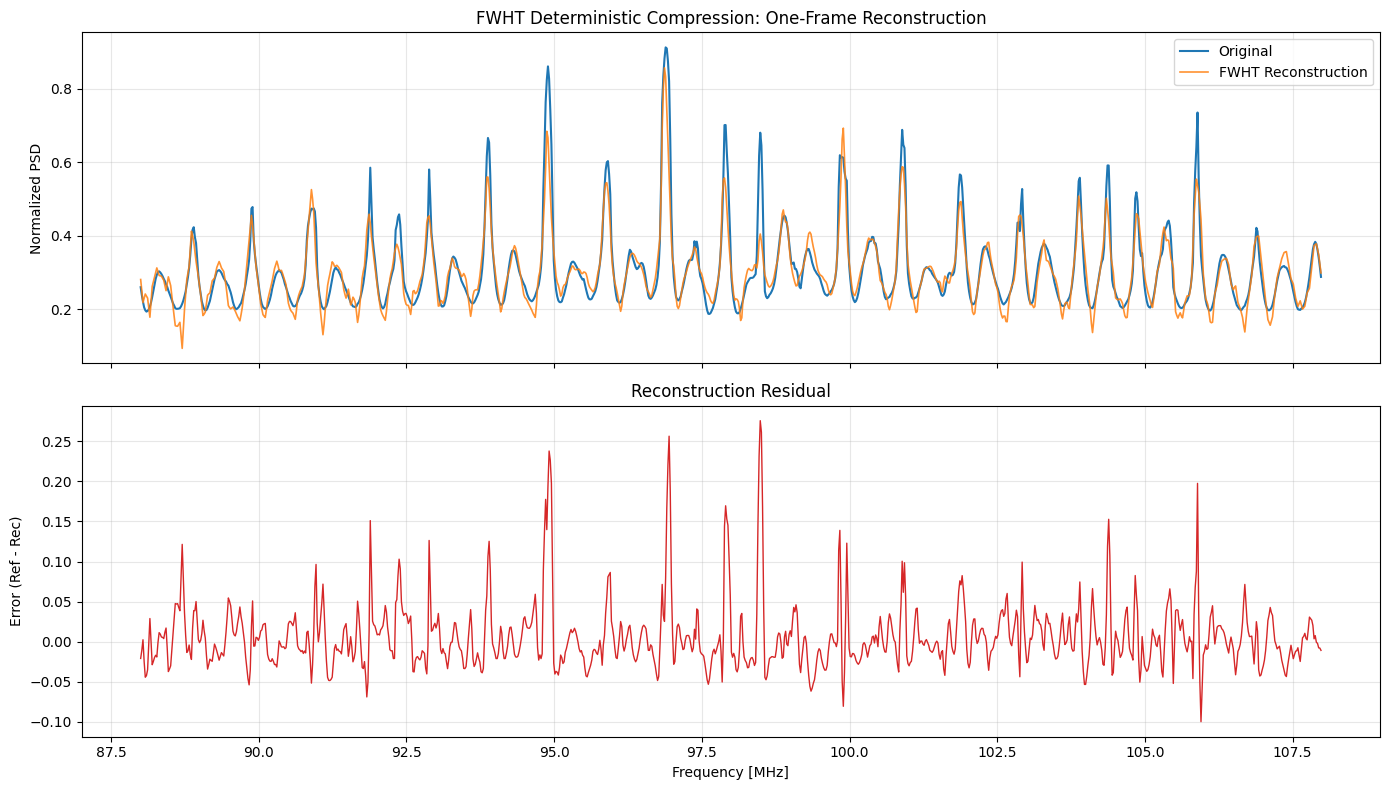

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot original and reconstructed PSD on the original frequency grid.
axes[0].plot(freqs_hz / 1e6, frame_reference, label="Original", linewidth=1.5)
axes[0].plot(freqs_hz / 1e6, frame_estimate, label="FWHT Reconstruction", linewidth=1.2, alpha=0.85)
axes[0].set_ylabel("Normalized PSD")
axes[0].set_title("FWHT Deterministic Compression: One-Frame Reconstruction")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot residual error to highlight structured distortion.
residual = frame_reference - frame_estimate
axes[1].plot(freqs_hz / 1e6, residual, color="tab:red", linewidth=1.0)
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Error (Ref - Rec)")
axes[1].set_title("Reconstruction Residual")
axes[1].grid(alpha=0.3)

plt.tight_layout()


Rate-distortion sweep over top-K coefficients
--------------------------------------------
     K     avg_bits      avg_mse     avg_nmse   avg_snr_db  avg_occ_mis
    16       458.00 5.278946e-03 4.870429e-02      13.1324 1.131210e-01
    32       858.00 3.371934e-03 3.109352e-02      15.0893 8.803558e-02
    64      1658.00 1.884963e-03 1.738386e-02      17.6158 5.991364e-02
   128      3258.00 8.754229e-04 8.074755e-03      20.9562 4.254150e-02
   256      6458.00 3.344343e-04 3.084858e-03      25.1533 2.853394e-02


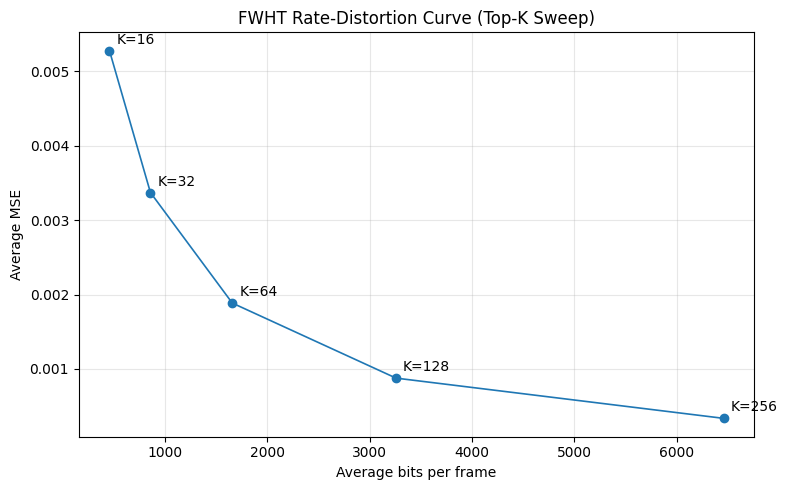

In [10]:
# Sweep K to visualize the FWHT rate-distortion trade-off.
K_VALUES = [16, 32, 64, 128, 256]
FRAME_SUBSET = range(min(128, frames_psd.shape[0]))

summary_rows: list[dict[str, float]] = []
for k_value in K_VALUES:
    cfg_k = replace(config, top_k=k_value)
    summary = evaluate_fwht_dataset(frames_psd, cfg_k, FRAME_SUBSET)
    summary_rows.append({"K": float(k_value), **summary})

print("Rate-distortion sweep over top-K coefficients")
print("--------------------------------------------")
header = (
    f"{'K':>6s} {'avg_bits':>12s} {'avg_mse':>12s} "
    f"{'avg_nmse':>12s} {'avg_snr_db':>12s} {'avg_occ_mis':>12s}"
)
print(header)
for row in summary_rows:
    print(
        f"{int(row['K']):6d} "
        f"{row['avg_bits_per_frame']:12.2f} "
        f"{row['avg_mse']:12.6e} "
        f"{row['avg_nmse']:12.6e} "
        f"{row['avg_snr_db']:12.4f} "
        f"{row['avg_occupancy_mismatch']:12.6e}"
    )

k_axis = [row["K"] for row in summary_rows]
bits_axis = [row["avg_bits_per_frame"] for row in summary_rows]
mse_axis = [row["avg_mse"] for row in summary_rows]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bits_axis, mse_axis, marker="o", linewidth=1.2)
for k_value, x_bits, y_mse in zip(k_axis, bits_axis, mse_axis):
    ax.annotate(f"K={int(k_value)}", (x_bits, y_mse), textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Average bits per frame")
ax.set_ylabel("Average MSE")
ax.set_title("FWHT Rate-Distortion Curve (Top-K Sweep)")
ax.grid(alpha=0.3)
plt.tight_layout()
